In [1]:
import torch
import torch.nn.functional as F #调用神经网络工具
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt','r').read().splitlines()#打开文件，读取模式，读取内容，分行显示
# words是一个list，每个元素是一个字符串，比如['emma','olivia','ava',...]

In [3]:
#对26个字母定义序号
chars = sorted(list(set(''.join(words))))

#string to integer  字符 -> 数字
stoi = {s:i+1 for i,s in enumerate(chars)}#enumerate实现自动编号功能 默认从0开始，且输出为元组：(编号, 元素)
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [4]:
import random
random.seed(42)
random.shuffle(words)#shuffle洗牌，讲所有名字打乱顺序

In [5]:
block_size = 3
def build_dataset(words):
    X,Y=[],[]

    for w in words:
        context = [0]*block_size#生成block_size(8)个数字为0的列表
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)#X这个列表中每次循环加入上一次循环结束的context
            Y.append(ix)#Y列表每次加入的是单词按顺序出现的字母对应的序号
            context = context[1:] + [ix]#每次循环按单词顺序加入一个字母
    #让X,Y从列表变成张量，便于数学运算
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape,Y.shape)
    return X,Y#return 只能存在于函数内部
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
for x,y in zip(Xtr[:16],Ytr[:16]):#zip像拉链一样把多个对象锁在一起，每次循环时，它同时从两个列表中各取出一个元素，打包成一个元组 (x_i, y_i)
    print(''.join(itos[ix.item()] for ix in x),'--->',itos[y.item()])#.join的作用是把列表里的字符拼接起来，".join"前面是说明用什么来拼接

... ---> y
..y ---> u
.yu ---> h
yuh ---> e
uhe ---> n
hen ---> g
eng ---> .
... ---> d
..d ---> i
.di ---> o
dio ---> n
ion ---> d
ond ---> r
ndr ---> e
dre ---> .
... ---> x


In [7]:
#mlp
n_embd = 10 #将每个token用10个数表示--10维空间中的某个坐标
n_hidden = 200 #隐藏层的神经元个数

g = torch.Generator().manual_seed(2147483647)#torch.Generator()创建随机数发生器

C = torch.randn((vocab_size,n_embd),            generator = g)
w1 = torch.randn((n_embd * block_size,n_hidden),generator = g) * (5/3)/((n_embd * block_size)**0.5) #每一组输入时block_size个字符，每个字符转化为token然后每个token用n_embd个数字表示
b1 = torch.randn(n_hidden,                      generator = g) * 0.01
w2 = torch.randn((n_hidden,vocab_size),         generator = g) * 0.01#torch.Size([200, 27])
b2 = torch.randn(vocab_size,                    generator = g) * 0

# BatchNorm parameters 通过标准化每一层的激活分布，使其均值和方差保持稳定，从而减少训练过程中的分布漂移，提高优化稳定性。 γ/β 保留模型的表达自由度
# 一个()和(())的区别是传入的数据类型不同，一个传入的是int 两个传入的是tuple
bngain = torch.ones((1,n_hidden))#1是为了后续广播 gamma
bnbias = torch.zeros((1,n_hidden))#1是为了后续广播 beta
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C,w1,b1,w2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters),C.shape,w1.shape,b1.shape,w2.shape,b2.shape) #nelement()计算所有元素的个数
for p in parameters:
    p.requires_grad = True

12297 torch.Size([27, 10]) torch.Size([30, 200]) torch.Size([200]) torch.Size([200, 27]) torch.Size([27])


In [8]:
max_step = 200000
batch_size = 32
lossi = []

for i in range(max_step):
    
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator = g)#()里有,代表是元组,没有逗号表示整数
    Xb,Yb = Xtr[ix],Ytr[ix]

    #forward pass
    emb = C[Xb]#从“索引”到“坐标” 输出(Xb[0],Xb[1],C[1])
    embcat = emb.view(emb.shape[0],-1)
    #linear layer
    hpreact = embcat @ w1 + b1 #隐藏层输出
    #BatchNorm layer
    #-----------------
    bnmeani = hpreact.mean(0,keepdim=True) #0代表把第 0 压扁了，keepdim=True是保留原来的维度，默认keepdim=False，择bnmeani.shape-->[200]
    bnstdi = hpreact.std(0,keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    #-----------------
    #Non-linearity
    h = torch.tanh(hpreact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits,Yb)# cross_entropy = softmax --> -log(y) -->mean()
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i<100000 else 0.001
    for p in parameters:
        p.data += - lr * p.grad

    #track stats
    if i %10000 == 0:
        print(f'{i:7d}/{max_step:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3522
 120000/ 200000: 2.0140
 130000/ 200000: 2.4561
 140000/ 200000: 2.3977
 150000/ 200000: 2.1819
 160000/ 200000: 1.9700
 170000/ 200000: 1.8837
 180000/ 200000: 2.0412
 190000/ 200000: 1.8451


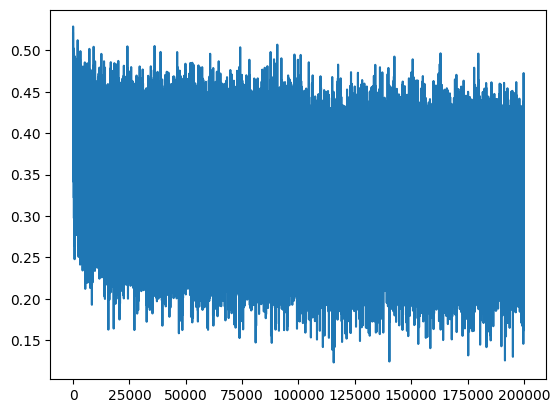

In [9]:
plt.plot(lossi)

In [10]:
#训练结束后进行批量归一化
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ w1 + b1
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)

In [12]:
@torch.no_grad()#把下面定义的函数，作为参数传给 @ 后面的东西。然后把返回值重新赋给参数
#wrapper = torch.no_grad()
#split_loss = wrapper(split_loss)
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte,Yte),
    }[split] #按照split的取值对x,y进行选择
    emb = C[x] #将每个输入变为10维的空间坐标 将离散的数据转换为向量，相近词意的内容会离得更近
    embcat = emb.view(emb.shape[0],-1)#压缩为2维
    hpreact = embcat @ w1 + b1
    #bnmean = hpreact.mean(0,keepdim=True)
    #bnstd = hpreact.std(0,keepdim=True)
    #hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits,y)
    print(split,loss.item())
split_loss('train')
split_loss('val')

train 2.071901559829712
val 2.106654405593872


In [14]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:

    def __init__(self,fan_in,fan_out,bias=True):
        self.weight = torch.randn((fan_in,fan_out),generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self,x):# x是前面设置的Xtr，Xdev，Xte
        self.out = x @ welf.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):#collect the parameters which called Robust for easy manage 调用者不需要手动检查这一层有没有偏置。
        return [self.weight]+([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self,dim,eps=1e-5,momentum=0.1): #dim指输入时的维度--每一层神经元的数量，eps是一个很小的数--ϵ，momentum（动量）作用于running_mean和running_var
        self.dim = dim
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')   
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self,x):
        if self.training:#self.training用于指示当前模型正处于训练模式（True）还是评估/测试模式（False）
            xmean = x.mean(0,keepdim=True)
            xvar = x.var(0,keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat +self.beta
        # update the buffers
        self.running_mean = (1 - momentum) * self.running_mean + momentum * xmean
        self.running_var = (1 - momentum) * self.running_var + momentum * xvar    
        return self.out
    def parameters(self):
        return(self.gamma,self.beta)

class Tanh:

    def __call__(self,x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []#保证调用parameters时不会报错

n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size,n_embd),generator = g) 
layers = [
    Linear(n_embd * block_size,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),#Linear--输入token维度 * 上下文长度，BatchNor1md--对每个隐藏的神经元进行归一化
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,n_hidden,bias = False),BatchNorm1d(n_hidden),Tanh(),
    Linear(n_hidden,vocab_size,bias = False),BatchNorm1d(vocab_size)
]

#=====初始化阶段=====
#decrease the last layer's confident to improve the calibration
with torch.no_grad():
    layers[-1].gamma *= 0.1
    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))#nelement() --number of element--是 PyTorch Tensor 类的一个方法，用于返回张量中所包含的元素总数
for p in parameters:
    p.requires_grad = True
#===================

47024
